# 03 — Modelling (M3)

Trains four models on identical stratified 5-fold splits and writes
per-fold + summary metrics to `artifacts/results.json`:

1. **Logistic regression** — linear baseline
2. **Random forest** — non-linear tabular baseline
3. **LSTM** — sequential model on 48-month payment trajectories (SMOTE per fold)
4. **TabNet** — attention-based tabular model, two variants (augmented + real-only)
   so M2 has the ablation comparison for free.

All four use the same fold indices (`cv.build_folds`, cached to
`artifacts/fold_indices.npz`) so scores are directly comparable.

**Prereqs** (once): `pip install -r requirements.txt`


## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display

from config import CFG, set_global_seeds
set_global_seeds()
print(f"device={CFG.device} | seed={CFG.seed} | n_folds={CFG.n_folds}")
print(f"data_dir={CFG.data_dir}")
print(f"artifacts_dir={CFG.artifacts_dir}")

device=cuda | seed=42 | n_folds=5
data_dir=D:\git-repos\DeepLearning\Project_work\Deep-Learning-Mini-Project\data
artifacts_dir=D:\git-repos\DeepLearning\Project_work\Deep-Learning-Mini-Project\M3_training_models\artifacts


## 2. Data sanity checks

Confirms M1's exports load, the `DEFAULT_LABEL` column is present, and
`sequences.npy` is row-aligned with `features.csv`.


In [2]:
from data import load_tabular, load_sequences

X, y, feat_names = load_tabular()
print(f"features.csv:  X={X.shape}  y={y.shape}  positives={y.sum()}/{len(y)} ({y.mean():.1%})")
print(f"first 8 features: {feat_names[:8]}")

seq, y_seq = load_sequences()
print(f"sequences.npy: seq={seq.shape}  y={y_seq.shape}")
assert (y == y_seq).all(), "label vectors disagree — row alignment broken"
print("✓ label vectors agree (row alignment OK)")

[data] auto-dropped non-numeric columns: ['EMPLOYER ID']
features.csv:  X=(1000, 9)  y=(1000,)  positives=253/1000 (25.3%)
first 8 features: ['TOTAL_ARREARS', 'MAX_CONSECUTIVE_MISSED', 'AVG_CONTRIBUTION_RATIO', 'SANCTION_SEVERITY', 'PAYMENT_RATE', 'AMOUNT_CV', 'AMOUNT_TREND', 'EMPLOYER_TENURE']
sequences.npy: seq=(1000, 48, 6)  y=(1000,)
✓ label vectors agree (row alignment OK)


## 3. Build shared 5-fold splits

In [3]:
from cv import build_folds

folds = build_folds(y)  # force=True regenerates; drop it on later runs

[cv] fold 0: train n=800 pos=0.254 | val n=200 pos=0.250
[cv] fold 1: train n=800 pos=0.254 | val n=200 pos=0.250
[cv] fold 2: train n=800 pos=0.253 | val n=200 pos=0.255
[cv] fold 3: train n=800 pos=0.253 | val n=200 pos=0.255
[cv] fold 4: train n=800 pos=0.253 | val n=200 pos=0.255


## 4. Baseline: logistic regression

Scaled features, class-weighted, no augmentation — the reference floor.


In [4]:
from train_baselines import train_logreg
_ = train_logreg()

[data] auto-dropped non-numeric columns: ['EMPLOYER ID']
[logreg] fold 0: AUC=0.9921 F1=0.8723
[logreg] fold 1: AUC=0.9857 F1=0.8750
[logreg] fold 2: AUC=0.9899 F1=0.9091
[logreg] fold 3: AUC=0.9896 F1=0.8980
[logreg] fold 4: AUC=0.9999 F1=0.9903
[eval] wrote logreg -> results.json
[eval] saved roc_logreg.png
[eval] saved cm_logreg.png
[logreg] CV AUC = 0.9914 ± 0.0047


## 5. Baseline: random forest

In [5]:
from train_baselines import train_rf
_ = train_rf()

[data] auto-dropped non-numeric columns: ['EMPLOYER ID']
[rf] fold 0: AUC=0.9957 F1=0.9804
[rf] fold 1: AUC=0.9985 F1=0.9608
[rf] fold 2: AUC=1.0000 F1=0.9903
[rf] fold 3: AUC=0.9986 F1=0.9808
[rf] fold 4: AUC=1.0000 F1=1.0000
[eval] wrote rf -> results.json
[eval] saved roc_rf.png
[eval] saved cm_rf.png
[rf] CV AUC = 0.9986 ± 0.0016


## 6. LSTM on 48-month sequences

- Bidirectional LSTM, mean-pooled over time
- SMOTE applied to flattened sequences per fold, then reshaped back
- Class-weighted CE loss, AMP, cosine LR schedule, early stopping on val AUC


In [6]:
import numpy as np
from config import CFG

seq = np.load(CFG.sequences_npy)
print(f"shape: {seq.shape}")
print(f"has NaN: {np.isnan(seq).any()}  (count: {np.isnan(seq).sum()})")
print(f"has Inf: {np.isinf(seq).any()}")
print(f"\nper-feature stats:")
for i in range(seq.shape[-1]):
    vals = seq[:, :, i]
    print(f"  feat {i}: min={vals.min():>12.3g}  max={vals.max():>12.3g}  "
          f"mean={vals.mean():>12.3g}  std={vals.std():>12.3g}")

shape: (1000, 48, 6)
has NaN: False  (count: 0)
has Inf: False

per-feature stats:
  feat 0: min=           1  max=    4.91e+03  mean=        18.3  std=         129
  feat 1: min=         320  max=    9.61e+06  mean=    4.02e+04  std=    3.02e+05
  feat 2: min=        43.2  max=     1.3e+06  mean=    5.43e+03  std=    4.08e+04
  feat 3: min=           0  max=     1.3e+06  mean=    5.39e+03  std=    4.08e+04
  feat 4: min=   -6.37e+05  max=    5.86e+05  mean=         797  std=    2.37e+04
  feat 5: min=           0  max=           0  mean=           0  std=           0


In [7]:
from train_lstm import train_lstm
_ = train_lstm()

[lstm] dropping constant sequence features at indices: [5]
[lstm] fold 0: AUC=0.8464 F1=0.6457 Recall=0.8200
[lstm] fold 1: AUC=0.7823 F1=0.5607 Recall=0.6000
[lstm] fold 2: AUC=0.8795 F1=0.5562 Recall=0.9216
[lstm] fold 3: AUC=0.8581 F1=0.5222 Recall=0.9216
[lstm] fold 4: AUC=0.9153 F1=0.7333 Recall=0.8627
[eval] wrote lstm -> results.json
[eval] saved roc_lstm.png
[eval] saved cm_lstm.png
[lstm] CV AUC = 0.8563 Â± 0.0438


## 7. TabNet — augmented and real-only

Two runs so M2 can quantify the augmentation lift for their Phase 3 ablation.


In [5]:
from train_tabnet import train_tabnet
_ = train_tabnet("tabnet_augmented", augmented=True)

[data] auto-dropped non-numeric columns: ['EMPLOYER ID']

Early stopping occurred at epoch 107 with best_epoch = 87 and best_val_auc = 0.99813
[tabnet] fold 0: AUC=0.9981 F1=0.9174 Recall=1.0000

Early stopping occurred at epoch 76 with best_epoch = 56 and best_val_auc = 0.99787
[tabnet] fold 1: AUC=0.9979 F1=0.8850 Recall=1.0000

Early stopping occurred at epoch 49 with best_epoch = 29 and best_val_auc = 0.99645
[tabnet] fold 2: AUC=0.9964 F1=0.8095 Recall=1.0000

Early stopping occurred at epoch 65 with best_epoch = 45 and best_val_auc = 0.99632
[tabnet] fold 3: AUC=0.9963 F1=0.6296 Recall=1.0000

Early stopping occurred at epoch 28 with best_epoch = 8 and best_val_auc = 0.99961
[tabnet] fold 4: AUC=0.9996 F1=0.7183 Recall=1.0000
Successfully saved model at D:\git-repos\DeepLearning\Project_work\Deep-Learning-Mini-Project\M3_training_models\artifacts\weights\tabnet_augmented_lastfold.zip
[eval] wrote tabnet_augmented -> results.json
[eval] saved roc_tabnet_augmented.png
[eval] saved 

In [6]:
_ = train_tabnet("tabnet_realonly", augmented=False)

[data] auto-dropped non-numeric columns: ['EMPLOYER ID']

Early stopping occurred at epoch 45 with best_epoch = 25 and best_val_auc = 0.99733
[tabnet] fold 0: AUC=0.9973 F1=0.9703 Recall=0.9800

Early stopping occurred at epoch 51 with best_epoch = 31 and best_val_auc = 0.99573
[tabnet] fold 1: AUC=0.9957 F1=0.9333 Recall=0.9800

Early stopping occurred at epoch 49 with best_epoch = 29 and best_val_auc = 0.99961
[tabnet] fold 2: AUC=0.9996 F1=0.9804 Recall=0.9804

Early stopping occurred at epoch 60 with best_epoch = 40 and best_val_auc = 0.99724
[tabnet] fold 3: AUC=0.9972 F1=0.9608 Recall=0.9608

Early stopping occurred at epoch 70 with best_epoch = 50 and best_val_auc = 1.0
[tabnet] fold 4: AUC=1.0000 F1=1.0000 Recall=1.0000
Successfully saved model at D:\git-repos\DeepLearning\Project_work\Deep-Learning-Mini-Project\M3_training_models\artifacts\weights\tabnet_realonly_lastfold.zip
[eval] wrote tabnet_realonly -> results.json
[eval] saved roc_tabnet_realonly.png
[eval] saved cm_tabn

## 8. SHAP — feature attributions for TabNet

Uses the last-fold weights. `KernelExplainer` is slow (~1–5 min on 300
samples); skip this cell during iteration and re-run before writing up.


In [8]:
from explain import run_shap
#run_shap("tabnet_augmented", n_background=100, n_explain=300)
run_shap("tabnet_realonly", n_background=100, n_explain=300)

[data] auto-dropped non-numeric columns: ['EMPLOYER ID']
[shap] saved tabnet_native_attr_tabnet_realonly.png


100%|██████████| 200/200 [00:54<00:00,  3.66it/s]

[shap] saved shap_beeswarm_tabnet_realonly.png


## 9. Final comparison table

In [9]:
from evaluate import build_comparison_table
build_comparison_table()

Model                                AUC             F1         Recall      Precision
-------------------------------------------------------------------------------------
logreg                    0.991 ± 0.005   0.909 ± 0.043   0.881 ± 0.063   0.940 ± 0.022
rf                        0.999 ± 0.002   0.982 ± 0.013   0.996 ± 0.008   0.969 ± 0.020
lstm                      0.856 ± 0.044   0.604 ± 0.077   0.825 ± 0.119   0.492 ± 0.099
tabnet_augmented          0.998 ± 0.001   0.792 ± 0.106   1.000 ± 0.000   0.668 ± 0.144
tabnet_realonly           0.998 ± 0.002   0.969 ± 0.022   0.980 ± 0.012   0.959 ± 0.037


## 10. Inline plot gallery

Every ROC + confusion matrix + SHAP plot generated above, rendered
inline for the report.


cm_logreg.png


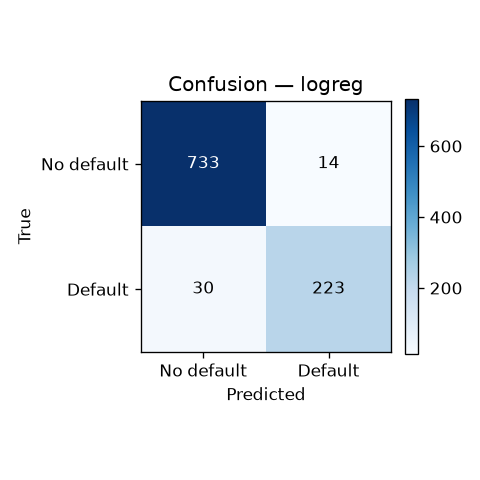

cm_lstm.png


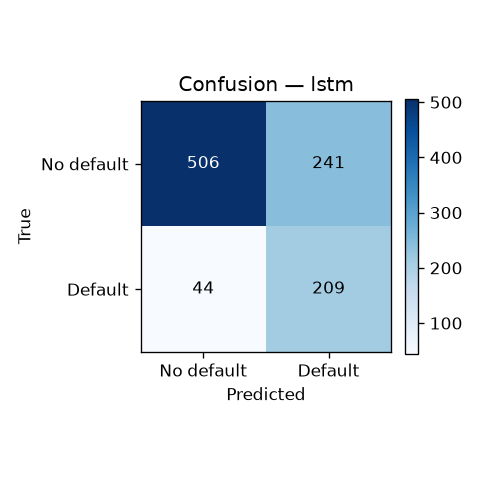

cm_rf.png


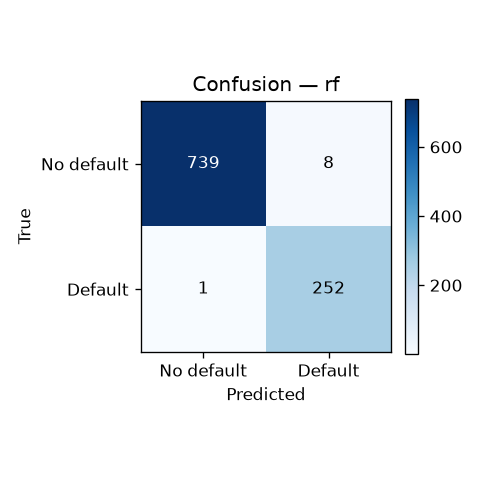

cm_tabnet_augmented.png


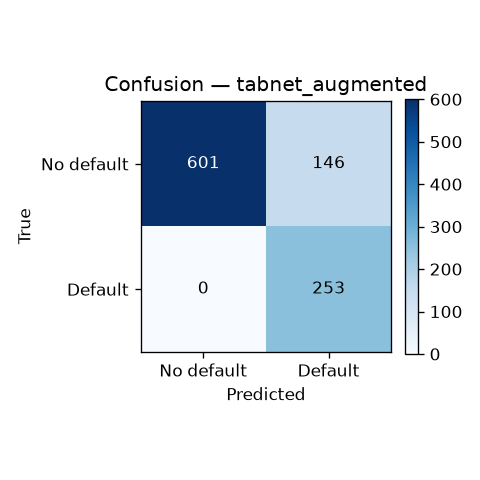

cm_tabnet_realonly.png


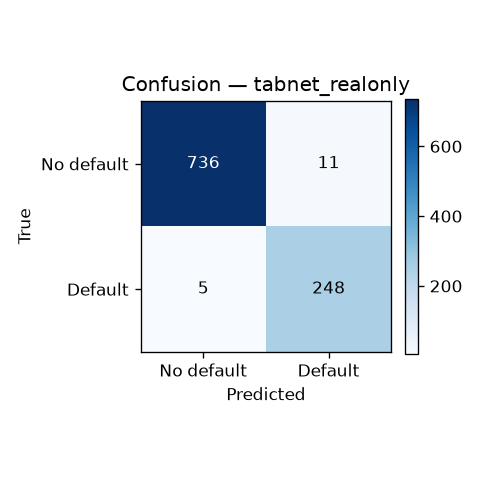

roc_logreg.png


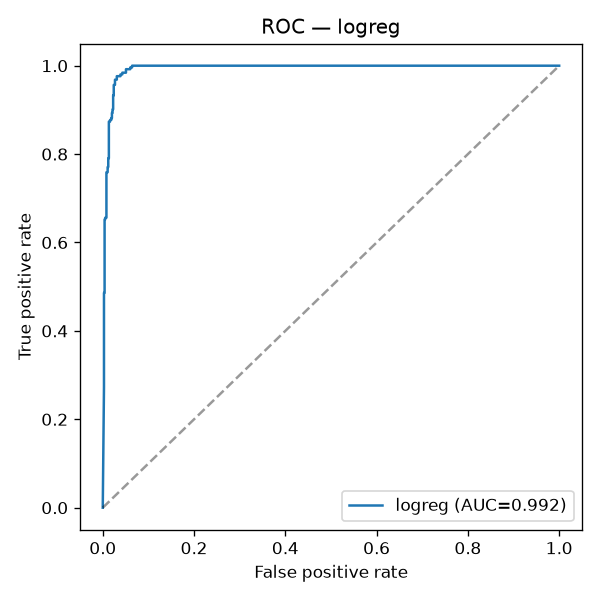

roc_lstm.png


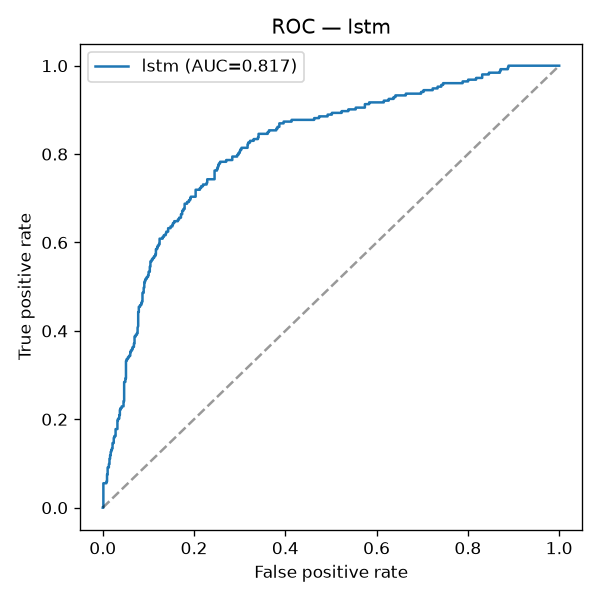

roc_rf.png


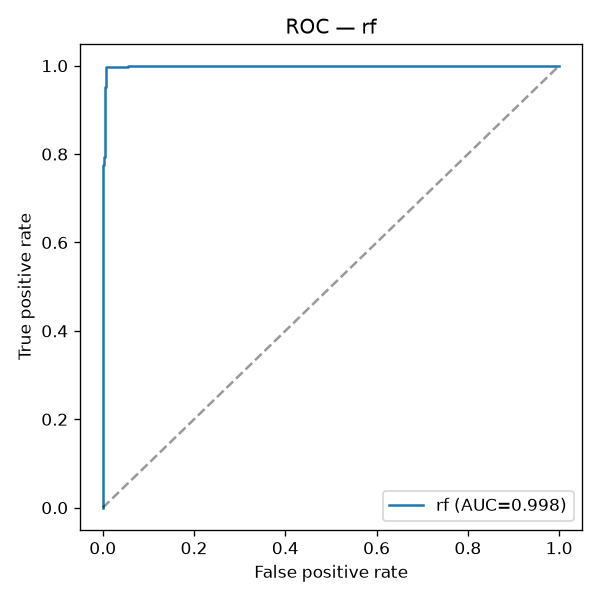

roc_tabnet_augmented.png


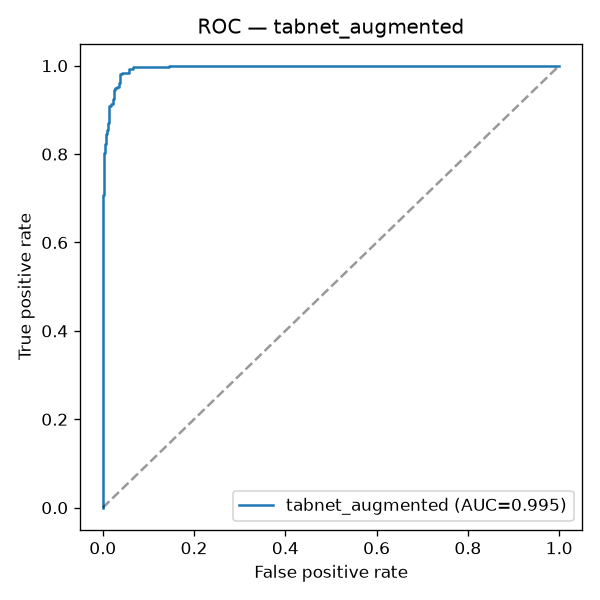

roc_tabnet_realonly.png


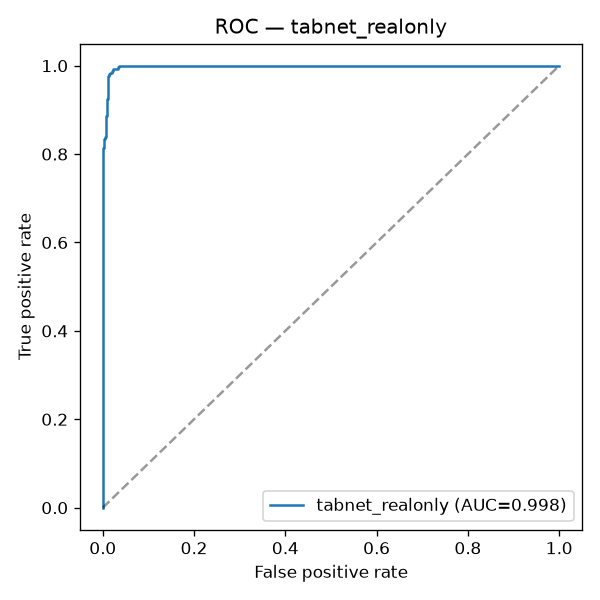

shap_beeswarm_tabnet_realonly.png


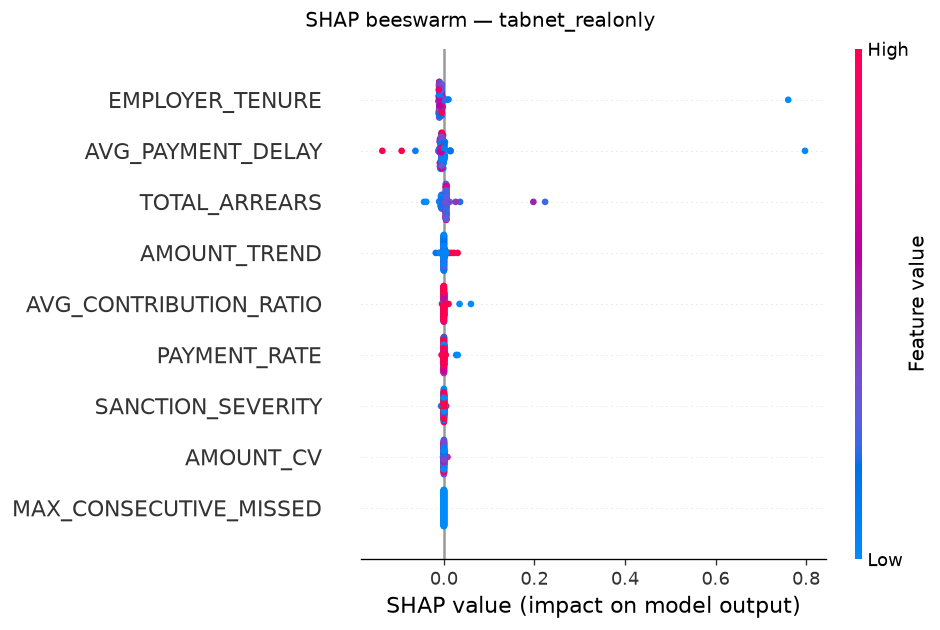

tabnet_native_attr_tabnet_realonly.png


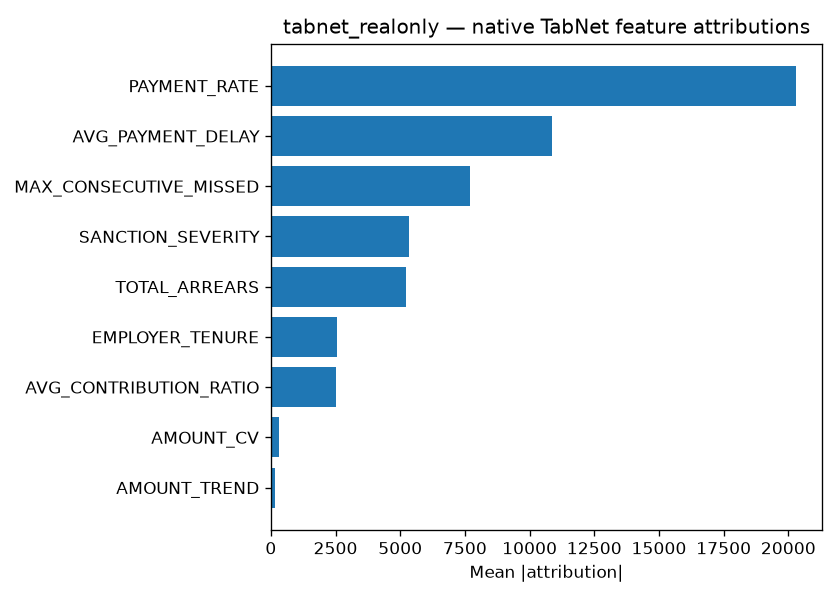

In [10]:
from pathlib import Path
plot_dir = CFG.artifacts_dir / "plots"
for p in sorted(plot_dir.glob("*.png")):
    print(p.name)
    display(Image(filename=str(p)))

## 11. Peek at raw fold-level results

Useful for the report: shows fold-to-fold variance, not just means.


In [11]:
import json
results = json.loads(CFG.results_json.read_text())
rows = []
for model, entry in results.items():
    for k, m in enumerate(entry["per_fold"]):
        rows.append({"model": model, "fold": k, **m})
per_fold_df = pd.DataFrame(rows)
per_fold_df

,model,fold,auc,f1,recall,precision
0,logreg,0,0.992133,0.872340,0.820000,0.931818
1,logreg,1,0.985667,0.875000,0.840000,0.913043
2,logreg,2,0.989933,0.909091,0.882353,0.937500
3,logreg,3,0.989604,0.897959,0.862745,0.936170
4,logreg,4,0.999868,0.990291,1.000000,0.980769
5,rf,0,0.995733,0.980392,1.000000,0.961538
6,rf,1,0.998533,0.960784,0.980000,0.942308
7,rf,2,1.000000,0.990291,1.000000,0.980769
8,rf,3,0.998552,0.980769,1.000000,0.962264
9,rf,4,1.000000,1.000000,1.000000,1.000000


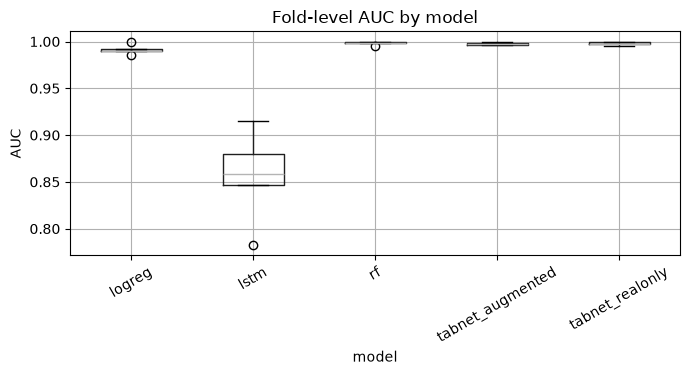

In [12]:
# Boxplot of fold-level AUC across models — quick visual sanity check
fig, ax = plt.subplots(figsize=(7, 4))
per_fold_df.boxplot(column="auc", by="model", ax=ax, rot=30)
ax.set_title("Fold-level AUC by model"); ax.set_ylabel("AUC")
plt.suptitle(""); plt.tight_layout(); plt.show()

---
### Handoff notes

- `artifacts/results.json` — machine-readable summary, per-model
- `artifacts/plots/` — all ROC / CM / SHAP PNGs for the report
- `artifacts/weights/` — last-fold TabNet + LSTM weights (SHAP loads TabNet's)
- `artifacts/fold_indices.npz` — cached splits; delete to regenerate

If M2 updates `augmentation.py`, only `aug_wrapper.py` needs to change.
If the LSTM constraint switches to from-scratch, only `models/lstm.py` needs to change.
